# Dementia Classifier
This notebook is a record of my attempt to develop a machine learning model that predicts the disease status of an image. It contains mulitple methods and iterations until my final model.

Step 1. Load packages and unzip the images.


In [35]:
# Import packages

# %pip install tensorflow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models, layers
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
print(f"TensorFlow Version: {tf.__version__}")
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

#%pip install scikit-learn
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import label_binarize

#%pip install seaborn
import seaborn as sns

import matplotlib.pyplot as plt

import os

import numpy as np

from collections import Counter

import glob

import os

import zipfile

import cv2

from google.colab import drive
drive.mount('/content/drive')

## Loading the images into the script.


In [ ]:
# Local: data already lives in data/raw/ — no extraction needed.
# Colab: uncomment and update the lines below.
# zip_path = '/content/drive/MyDrive/...'
# extract_path = '/content/raw_data'

os.makedirs(extract_path, exist_ok=True)

# Unzips the folder into the raw_data folder.
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    for file in zip_ref.namelist():
        # Check if the file path contains the junk folders.
        if '__MACOSX' not in file and 'AD copy' not in file:
            zip_ref.extract(file, extract_path)

print("Data unzipped!")

# Verifies.
if os.path.exists(extract_path):
    print("Contents:", os.listdir(extract_path))
else:
    print("Folder not found!")

Data unzipped!
Contents: ['NoImpairment', 'ModerateImpairment', 'MildImpairment']


In [ ]:
basepath = '../data/raw'

# Our three classes
class_names = ['MildImpairment', 'ModerateImpairment', 'NoImpairment']
counts = []

# Loops through the classes list and creates the full path.
# Then outputs a list of all the items in the folder into 'files'.
# len() then counts the length of files, and the value is added to the counts list.

for class_name in class_names:
    full_path = os.path.join(basepath, class_name)
    files = glob.glob(os.path.join(full_path, "*.jpg"))
    counts.append(len(files))

print (f"There is: {counts[2]} NoImpairment images.")
print (f"There is: {counts[0]} MildImpairment images.")
print (f"There is: {counts[1]} ModerateImpairment images.")


There is: 2560 NoImpairment images.
There is: 1792 MildImpairment images.
There is: 724 ModerateImpairment images.


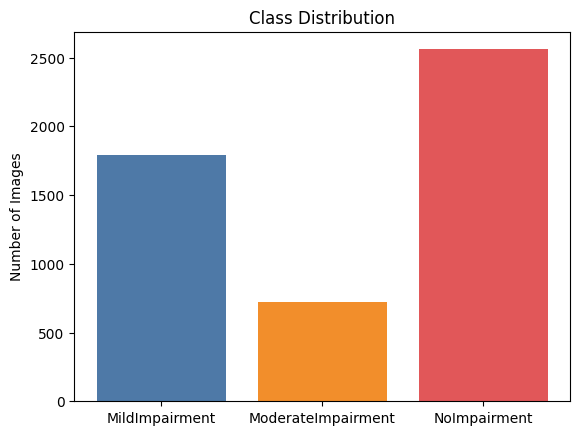

In [7]:
# Creates a bar chart of the distribution of data.
plt.bar(class_names, counts, color=['#4e79a7', '#f28e2b', '#e15759'])
plt.title ('Class Distribution')
plt.ylabel ('Number of Images')
plt.show()

## Creating the datasets



In [8]:
# Create the training dataset (80%)
train_ds = keras.utils.image_dataset_from_directory(
    basepath,
    image_size= (256,256),
    color_mode='grayscale',
    subset = "training",
    labels='inferred',
    validation_split=0.2,
    seed = 2614,
    shuffle = True
    )
# Creating the validation dataset (20%).
test_val_data = keras.utils.image_dataset_from_directory(
    basepath,
    image_size= (256, 256),
    color_mode='grayscale',
    labels='inferred',
    subset = "validation",
    validation_split=0.2,
    seed = 2614,
    shuffle = True)

# Split val/test
val_ds = test_val_data.take(len(test_val_data) // 2)
test_ds = test_val_data.skip(len(test_val_data) // 2)
print(f"Standard Datasets Ready: train_ds, val_ds, test_ds")
print(f"Shape: (256, 256, 1) - Grayscale")

Found 5076 files belonging to 3 classes.
Using 4061 files for training.
Found 5076 files belonging to 3 classes.
Using 1015 files for validation.
Standard Datasets Ready: train_ds, val_ds, test_ds
Shape: (256, 256, 1) - Grayscale


In [9]:
# Stops training early if val_loss doesn't improve 4 epochs in a row, restores back to the best epoch.
early_stopping_callback = EarlyStopping(
    monitor = 'val_loss',
    patience = 4,
    restore_best_weights = True
)

# Model 1

In [10]:
# A CNN with one layer.
modelv1 = models.Sequential([
    Input(shape=(256, 256, 1)), # 256 x 256 pixel images in greyscale
    Conv2D(filters=32, kernel_size=3, activation='relu'), # 32 feature maps at a time, looking in a 3x3 window.
    MaxPooling2D (2,2), # Selects 4 pixels and retains the highest signal, accelerates processing.
    Flatten(), # Turns it into a 1D array.
    Dropout(rate = 0.1), # Randomly turns off 10% of neurons: helps with overfitting.
    Dense(units = 3, activation = 'softmax') # Final classification is one of three classes.
])

In [11]:
# Adam is a stochastic gradient descent optimisation algorithm
modelv1.compile(optimizer = Adam(learning_rate = 0.003),
              loss = "sparse_categorical_crossentropy",
              metrics =['accuracy'])
modelv1.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 516128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 516128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │     1,548,387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,548,707 (5.91 MB)

 Trainable params: 1,548,707 (5.91 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Trains the data on the training data set, while testing on the validation dataset in between epochs.
historyv1 = modelv1.fit(train_ds, validation_data = val_ds,
    batch_size=32,
    epochs=20, shuffle=True,
    callbacks = [early_stopping_callback])


Epoch 1/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - accuracy: 0.4301 - loss: 1755.9559 - val_accuracy: 0.5293 - val_loss: 1.3316
Epoch 2/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.6657 - loss: 0.9130 - val_accuracy: 0.6094 - val_loss: 1.7226
Epoch 3/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.6451 - loss: 1.2145 - val_accuracy: 0.6602 - val_loss: 1.0877
Epoch 4/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.7469 - loss: 0.7016 - val_accuracy: 0.7012 - val_loss: 1.0265
Epoch 5/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.7738 - loss: 0.6652 - val_accuracy: 0.6914 - val_loss: 1.0279
Epoch 6/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.8530 - loss: 0.3860 - val_accuracy: 0.6855 - val_loss: 1.1173
Epoch 7/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.8447 - loss: 0.4383 - val_accuracy: 0.6875 - val_loss: 1.2661
Epoch 8/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.8198 - loss: 0.6007 - val

## Plotting accuracy and loss graphs for Model 1.

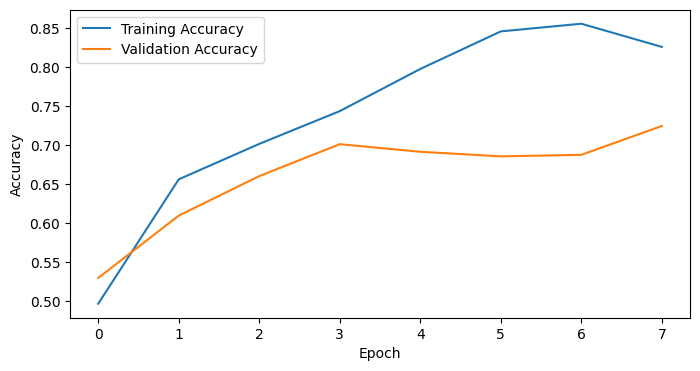

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - accuracy: 0.6697 - loss: 1.1700
Accuracy: 0.6819085478782654
Loss: 1.0252161026000977


In [13]:
# Plots training vs validation accuracy

epochv1 = historyv1.epoch

accv1 = historyv1.history['accuracy']
valaccv1 = historyv1.history['val_accuracy']

plt.figure(figsize=(8,4))
plt.plot(epochv1, accv1, label = 'Training Accuracy')
plt.plot(epochv1, valaccv1, label = 'Validation Accuracy')
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.show()

# Provides the loss and accuracy on the test dataset.
loss, accuracy = modelv1.evaluate(test_ds)
print(f"Accuracy: {accuracy}\nLoss: {loss}")

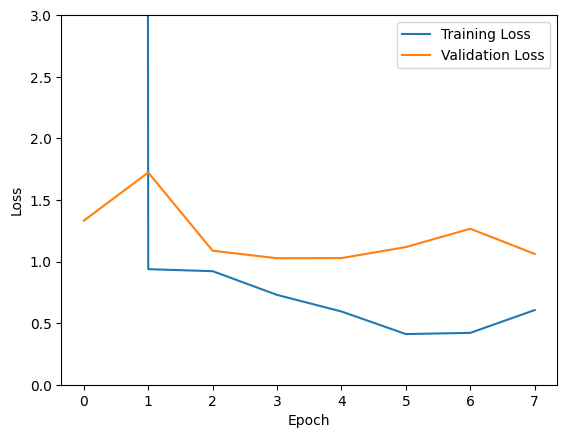

In [14]:
# Plots training vs validation loss
lossv1 = historyv1.history['loss']
vallossv1 = historyv1.history['val_loss']

plt.plot (epochv1, lossv1, label = 'Training Loss')
plt.plot (epochv1, vallossv1, label = 'Validation Loss')
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.ylim (0,3)
plt.legend(loc = 'upper right')
plt.show()

## Creating the classification report

In [15]:
# Create empty lists to hold the exact, locked order
y_true = []
x_test = []

# Extract both images and labels in a single loop
for images, labels in test_ds:
    x_test.extend(images.numpy())
    y_true.extend(labels.numpy())

# Convert to numpy arrays
x_test = np.array(x_test)
y_true = np.array(y_true)

# Generate predictions on the locked image array
y_prob = modelv1.predict(x_test)
y_pred = np.argmax(y_prob, axis=1)

# Print metrics
print(classification_report(y_true, y_pred, target_names=['MildImpairment', 'ModerateImpairment', 'NoImpairment']))

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
                    precision    recall  f1-score   support

    MildImpairment       0.73      0.57      0.64       180
ModerateImpairment       0.58      0.50      0.54        72
      NoImpairment       0.72      0.86      0.79       251

          accuracy                           0.71       503
         macro avg       0.68      0.64      0.65       503
      weighted avg       0.70      0.71      0.70       503



## Creating the confusion matrix

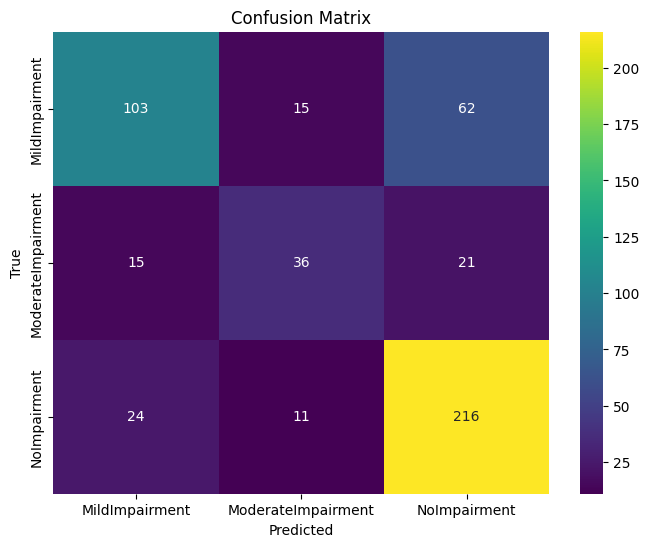

In [16]:
# Create the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot it using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## Creating a ROC Curve for Model 1

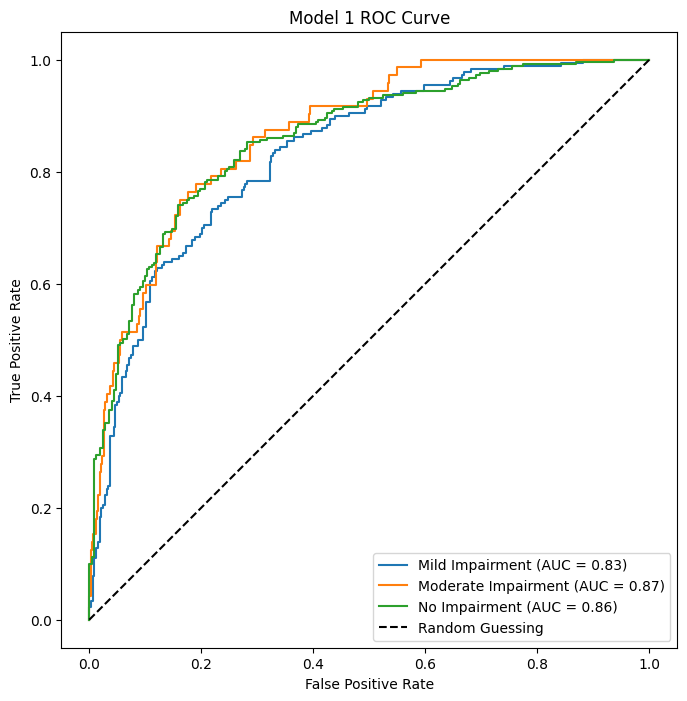

In [32]:
fig, ax1 = plt.subplots(figsize=(8, 8))

for class_id in range(3):
    binary_labels = (y_true == class_id)
    class_probabilities = y_prob[:, class_id]

    RocCurveDisplay.from_predictions(
        binary_labels,
        class_probabilities,
        name=f"{class_names[class_id]}",
        ax=ax1
    )

ax1.plot([0, 1], [0, 1], "k--", label="Random Guessing")
ax1.axis("square")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Model 1 ROC Curve")
ax1.legend()
plt.show()

# Second iteration of the model
#### The first model shows evidence of severe overfitting, so we do three things to address it:
- Data Augmentation
- Add multiple layers to the CNN
- Tune the learning rate

In [17]:
# This model randomly flips, rotates and zooms each image to prevent overfitting during training.
# Goes through 3 convolution layers, with filter doubling each time to learn more complex features.
modelv2 = models.Sequential([
    Input(shape=(256, 256, 1)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    Conv2D(filters=32, kernel_size=3, activation='relu'),
    MaxPooling2D (2,2),
    Conv2D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling2D (2,2),
    Conv2D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling2D (2,2),
    Flatten(),
    Dense(units=128, activation='relu'),
    Dropout(rate = 0.3),
    Dense(units = 3, activation = 'softmax')
])

class_weight_dict = ({
    0 : 1.022,
    1 : 2.306,
    2 : 0.630
})

In [18]:
modelv2.compile(optimizer = Adam(learning_rate = 0.0001),
              loss = "sparse_categorical_crossentropy",
              metrics =['accuracy'])
modelv2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 256, 256, 1)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 254, 254, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,838,787 (56.61 MB)

 Trainable params: 14,838,787 (56.61 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
historyv2 = modelv2.fit(train_ds, validation_data = val_ds,
batch_size=32,
epochs=20, shuffle=True,
class_weight = class_weight_dict,
callbacks = [early_stopping_callback])

Epoch 1/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - accuracy: 0.3538 - loss: 16.3327 - val_accuracy: 0.3418 - val_loss: 1.0988
Epoch 2/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - accuracy: 0.3934 - loss: 1.1200 - val_accuracy: 0.5684 - val_loss: 1.0657
Epoch 3/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - accuracy: 0.4276 - loss: 1.1131 - val_accuracy: 0.3203 - val_loss: 1.1010
Epoch 4/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.4521 - loss: 1.1039 - val_accuracy: 0.5664 - val_loss: 0.9926
Epoch 5/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.3781 - loss: 1.0931 - val_accuracy: 0.5410 - val_loss: 0.9771
Epoch 6/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.3525 - loss: 1.0837 - val_accuracy: 0.1426 - val_loss: 1.1070
Epoch 7/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.1653 - loss: 1.1187 - val_accuracy: 0.3184 - val_loss: 1.1066
Epoch 8/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - accuracy: 0.3583 - loss: 1.1278 - va

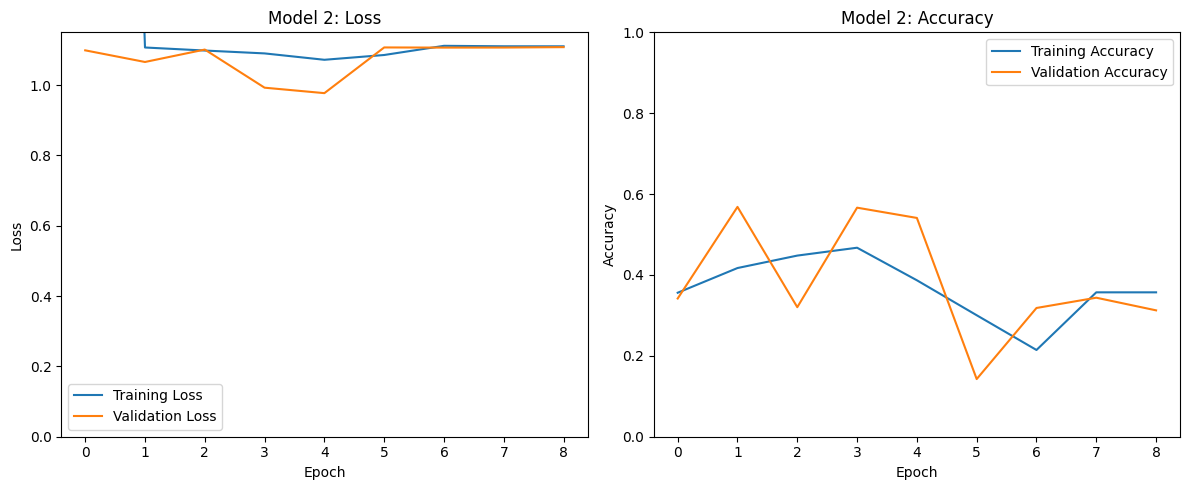

In [20]:
# Extracting data for Model 2
epochv2 = historyv2.epoch
lossv2 = historyv2.history['loss']
vallossv2 = historyv2.history['val_loss']
accv2 = historyv2.history['accuracy']
valaccv2 = historyv2.history['val_accuracy']

# Create a 1x2 grid for side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Model 2 Loss
ax1.plot(epochv2, lossv2, label='Training Loss')
ax1.plot(epochv2, vallossv2, label='Validation Loss')
ax1.set_title("Model 2: Loss")
ax1.set_ylabel("Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylim(0, 1.15)
ax1.legend()

# Plot 2: Model 2 Accuracy
ax2.plot(epochv2, accv2, label='Training Accuracy')
ax2.plot(epochv2, valaccv2, label='Validation Accuracy')
ax2.set_title("Model 2: Accuracy")
ax2.set_ylabel("Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylim(0, 1)
ax2.legend()

plt.tight_layout()
plt.show()

# Creating the classification report

In [21]:
y_prob_2 = modelv2.predict(x_test)
y_pred_2 = np.argmax(y_prob_2, axis=1)

print("--- Model 2 Classification Report ---")
print(classification_report(y_true, y_pred_2, target_names=['MildImpairment', 'ModerateImpairment', 'NoImpairment']))

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step
--- Model 2 Classification Report ---
                    precision    recall  f1-score   support

    MildImpairment       0.41      0.09      0.15       180
ModerateImpairment       0.26      0.74      0.38        72
      NoImpairment       0.69      0.72      0.71       251

          accuracy                           0.50       503
         macro avg       0.45      0.51      0.41       503
      weighted avg       0.53      0.50      0.46       503



# Creating the confusion matrix

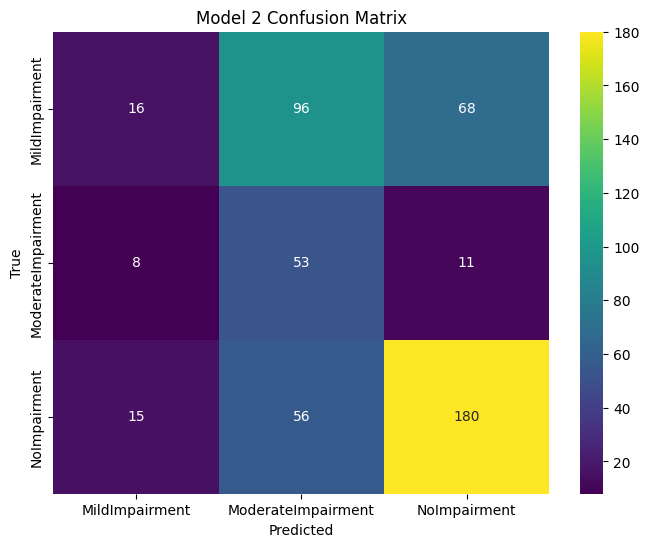

In [22]:
# Create the confusion matrix
cm = confusion_matrix(y_true, y_pred_2)

# Plot it using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Model 2 Confusion Matrix')
plt.show()

# Creating the ROC Curve

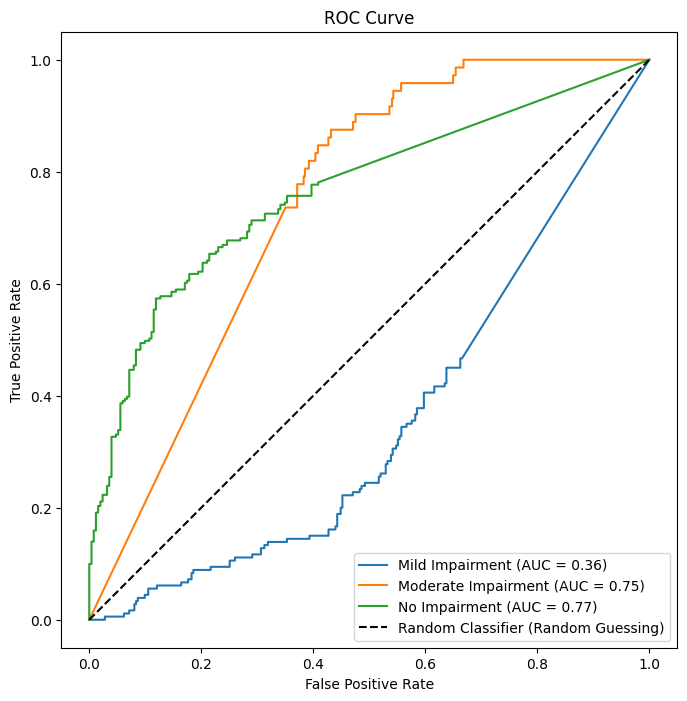

In [33]:
# Creates a ROC curve.
fig, ax = plt.subplots(figsize=(8,8))

# Loops through each class and generates a "One-vs-Rest" curve for each.
for class_id in range(3):
    binary_labels = (y_true == class_id) # Binarize the labels.
    class_probabilities = y_prob_2[:, class_id] # Select the probability column corresponding to the current class.
    RocCurveDisplay.from_predictions( # Plot ROC curve
        binary_labels,
        class_probabilities,
        name=f"{class_names[class_id]}",
        ax=ax
    )

plt.plot([0,1], [0,1], "k--", label = "Random Classifier (Random Guessing)") # Plots the diagonal line representing the random classifier.
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

# Model 3: Using ResNet

In [26]:
# Load Base ResNet
base_resnet = keras.applications.ResNet50(
    include_top=False, # Removes the final classification layer
    weights='imagenet', # Uses the weights tuned from pre-trained images.
    input_shape=(224, 224, 3), # Standard ResNet shape
    pooling='avg' # Turn the 3D output into 1D vector, replaces Flatten()
)
base_resnet.trainable = False

# Unfreezes the final 5 layers, except batch normalisations.
for layer in base_resnet.layers[-5:]:
    if "bn" not in layer.name:
        layer.trainable = True

modelv3 = models.Sequential([
    Input(shape=(256, 256, 1)),

    # Data Augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05), # 5% rotation

    # Adapter Block (Adjusts shape/color for ResNet)
    layers.Resizing(224, 224),
    layers.Lambda(lambda x: tf.image.grayscale_to_rgb(x)), # 1 Channel -> 3 Channels

    # Pre-trained Base
    base_resnet,

    # Classification layers at the end
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(3, activation='softmax')
])

modelv3.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

modelv3.summary()

class_weight_dict = ({
    0 : 1.022,
    1 : 2.306,
    2 : 0.630
})

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 256, 256, 1)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,371 (90.98 MB)

 Trainable params: 1,313,283 (5.01 MB)

 Non-trainable params: 22,537,088 (85.97 MB)

In [ ]:
historyv3 = modelv3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight = class_weight_dict,
    shuffle=True
)

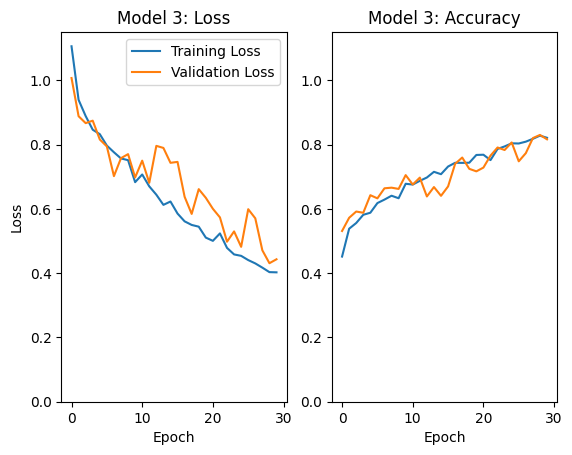

In [28]:
# Produces loss and accuracy graphs.
epochv3 = historyv3.epoch
lossv3 = historyv3.history['loss']
vallossv3 = historyv3.history['val_loss']
accv3 = historyv3.history['accuracy']
valaccv3 = historyv3.history ['val_accuracy']


fig, (ax1, ax2) = plt.subplots(1,2)

ax1.plot (epochv3, lossv3, label = 'Training Loss')
ax1.plot (epochv3, vallossv3, label = 'Validation Loss')
ax1.set_title("Model 3: Loss")
ax1.set_ylabel("Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylim(0,1.15)
ax1.legend()

ax2.plot (epochv3, accv3, label = 'Training Accuracy')
ax2.plot (epochv3, valaccv3, label = 'Validation Training Accuracy')
ax2.set_title("Model 3: Accuracy")
ax2.set_ylim(0,1.15)
ax2.set_xlabel("Epoch")

plt.show()

# Creating the classification table

--- Model 3 Classification Report ---
                    precision    recall  f1-score   support

    MildImpairment       0.75      0.84      0.79       180
ModerateImpairment       0.81      0.61      0.70        72
      NoImpairment       0.85      0.83      0.84       251

          accuracy                           0.81       503
         macro avg       0.80      0.76      0.78       503
      weighted avg       0.81      0.81      0.80       503



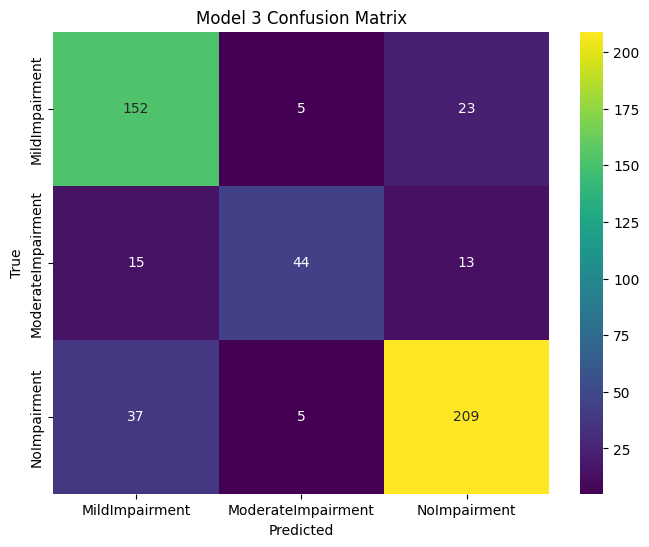

In [29]:
# Generate prediction probabilities
y_prob_3 = modelv3.predict(x_test, verbose=0)

# Convert probabilities to class labels
y_pred_3 = np.argmax(y_prob_3, axis=1)

# Print the final classification report
print("--- Model 3 Classification Report ---")
print(classification_report(y_true, y_pred_3, target_names=class_names))

# Create and plot the confusion matrix
cm_3 = confusion_matrix(y_true, y_pred_3)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_3, annot=True, fmt='d', cmap='viridis',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Model 3 Confusion Matrix')
plt.show()

# Creating a ROC Curve for Model 3


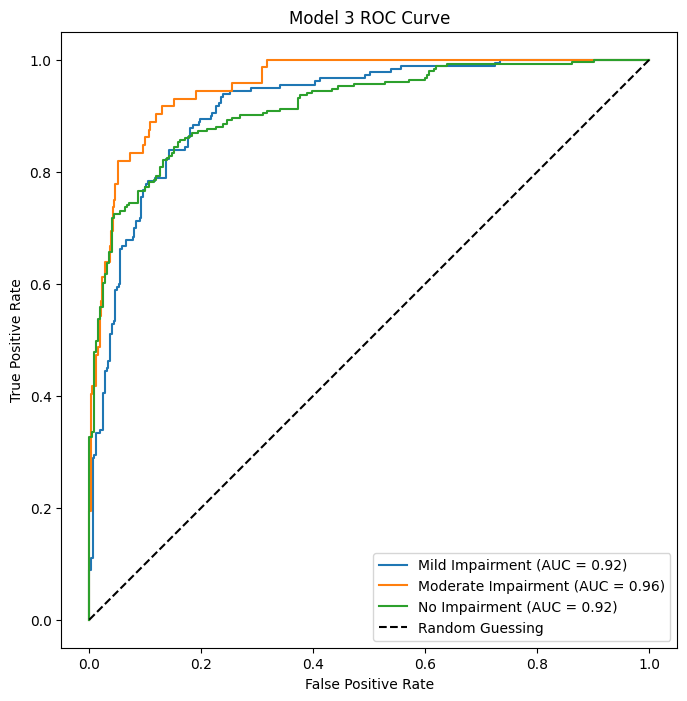

In [30]:
fig, ax = plt.subplots(figsize=(8, 8))

for class_id in range(3):
    binary_labels = (y_true == class_id)
    class_probabilities = y_prob_3[:, class_id]

    RocCurveDisplay.from_predictions(
        binary_labels,
        class_probabilities,
        name=f"{class_names[class_id]}",
        ax=ax
    )

plt.plot([0, 1], [0, 1], "k--", label="Random Guessing")
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model 3 ROC Curve")
plt.legend()
plt.show()

# ROC Curve of all Three Models

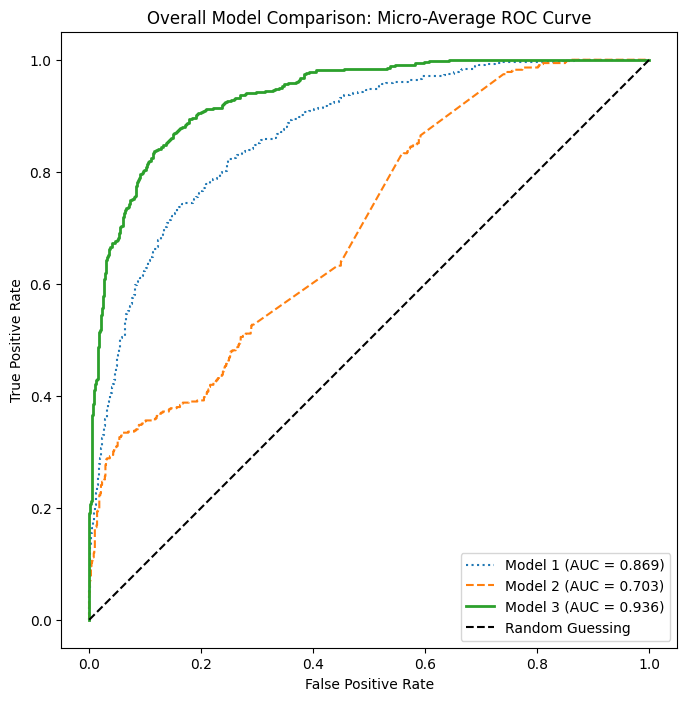

In [37]:
# Binarize true labels for multi-class micro-average computation
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

# Helper function to compute micro-average ROC and AUC
def compute_micro_roc(y_true_b, y_prob):
    fpr, tpr, _ = roc_curve(y_true_b.ravel(), y_prob.ravel())
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc

# Calculate metrics for all three models
fpr1, tpr1, auc1 = compute_micro_roc(y_true_bin, y_prob)
fpr2, tpr2, auc2 = compute_micro_roc(y_true_bin, y_prob_2)
fpr3, tpr3, auc3 = compute_micro_roc(y_true_bin, y_prob_3)

# Plot the comparative ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr1, tpr1, linestyle=':', label=f'Model 1 (AUC = {auc1:.3f})')
plt.plot(fpr2, tpr2, linestyle='--', label=f'Model 2 (AUC = {auc2:.3f})')
plt.plot(fpr3, tpr3, linewidth=2, label=f'Model 3 (AUC = {auc3:.3f})')

# Plot random guessing baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')

plt.axis('square')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Overall Model Comparison: Micro-Average ROC Curve')
plt.legend(loc='lower right')
plt.show()